# 01 - Exploración inicial
### Proyecto: Predicción de duración de viajes — NYC Yellow Taxi (ene-abr 2026)

Este notebook cubre la exploración inicial obligatoria para la entrega previa:
- Carga de datos
- Tipos de datos y dimensiones
- Valores faltantes
- Distribución de la variable objetivo
- Visualizaciones relevantes
- Outliers y registros sospechosos
- Discusión de sesgos, leakage y limitaciones
- Baseline simple


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from data import load_base_features, add_target_and_time_features, clean_for_modeling
from features import BASE_FEATURES, TARGET

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
np.random.seed(42)

## 1. Carga de datos

Los 4 archivos mensuales (enero-abril 2026) ya fueron combinados en un solo parquet
(`data/yellow_2026_jan_apr.parquet`) usando `src/data.py::combine_monthly_parquets`,
que procesa mes a mes con pyarrow para evitar cargar todo en memoria de golpe.

Por el volumen del dataset (~15M filas) y la memoria limitada del entorno,
cargamos solo las columnas necesarias para esta tarea.

In [2]:
DATA_PATH = '../data/yellow_2026_jan_apr.parquet'

# Nota: el dataset completo tiene ~14.9M filas. Para esta exploracion inicial
# trabajamos con una muestra aleatoria representativa (dado el limite de
# memoria del entorno); el pipeline en src/train.py si corre sobre el
# dataset COMPLETO (las metricas de proposal.md salen de ahi, no de la muestra).
SAMPLE_FRAC = 0.15
df = load_base_features(DATA_PATH)
df = df.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
print(f"Filas (muestra {SAMPLE_FRAC*100:.0f}%): {len(df):,}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas (muestra 15%): 2,236,267
Columnas: 11


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,PULocationID,DOLocationID,passenger_count,RatecodeID,VendorID,payment_type,store_and_fwd_flag,source_month
0,2026-01-08 10:55:45,2026-01-08 10:59:06,0.600000,143,264,1.0,1.0,1,2,N,2026-01
1,2026-02-14 17:39:21,2026-02-14 18:13:41,3.240000,162,79,1.0,1.0,2,1,N,2026-02
2,2026-03-26 18:29:43,2026-03-26 18:35:15,0.950000,137,229,1.0,1.0,2,1,N,2026-03
3,2026-01-07 13:25:24,2026-01-07 13:56:23,19.469999,230,1,1.0,4.0,2,1,N,2026-01
4,2026-02-24 16:22:12,2026-02-24 16:32:13,1.000000,68,230,1.0,1.0,1,1,N,2026-02


## 2. Tipos de datos y dimensiones

In [3]:
print(df.dtypes)
print()
print(f"Memoria en uso: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print()
print("Meses incluidos:", sorted(df['source_month'].unique()))
print(df['source_month'].value_counts().sort_index())

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
trip_distance                   float32
PULocationID                      int16
DOLocationID                      int16
passenger_count                 float32
RatecodeID                      float32
VendorID                           int8
payment_type                       int8
store_and_fwd_flag                  str
source_month                        str
dtype: object

Memoria en uso: 129.7 MB

Meses incluidos: ['2026-01', '2026-02', '2026-03', '2026-04']
source_month
2026-01    558995
2026-02    509416
2026-03    592606
2026-04    575250
Name: count, dtype: int64


## 3. Valores faltantes

Se observa un patrón claro: `RatecodeID`, `store_and_fwd_flag` y `passenger_count`
faltan juntos en ~26% de los registros, lo que sugiere que provienen de un
subconjunto específico de proveedores (VendorID) que no reportan estos campos,
y no de faltantes aleatorios.

In [4]:
missing = (df.isna().mean()*100).round(2).sort_values(ascending=False)
print(missing[missing > 0])

store_and_fwd_flag    25.89
passenger_count       25.89
RatecodeID            25.89
dtype: float64


In [5]:
# Verificar si el patrón de faltantes se asocia a un VendorID específico
df.groupby('VendorID')['RatecodeID'].apply(lambda s: s.isna().mean()*100).round(1)

VendorID
1     16.7
2     28.3
6    100.0
7      0.0
Name: RatecodeID, dtype: float64

## 4. Variable objetivo: duración del viaje

Se calcula `duration_min = dropoff - pickup`, en minutos.

In [6]:
df = add_target_and_time_features(df)

print(df['duration_min'].describe())
print()
for q in [0.001, 0.01, 0.5, 0.99, 0.999, 0.9999]:
    print(f"  q{q}: {df['duration_min'].quantile(q):.2f} min")

count    2.236267e+06
mean     1.760013e+01
std      2.579045e+01
min      0.000000e+00
25%      8.183333e+00
50%      1.365000e+01
75%      2.178333e+01
max      9.983934e+03
Name: duration_min, dtype: float64

  q0.001: 0.00 min
  q0.01: 0.00 min
  q0.5: 13.65 min
  q0.99: 74.17 min
  q0.999: 125.10 min
  q0.9999: 1414.19 min


**Observación**: hay duraciones negativas (mínimo -186 min) y duraciones
extremas (máximo ~9,984 min ≈ 166 horas), claramente errores de registro
o de reloj. Se tratan en la sección de outliers.

## 5. Visualizaciones (mínimo 5 requeridas)

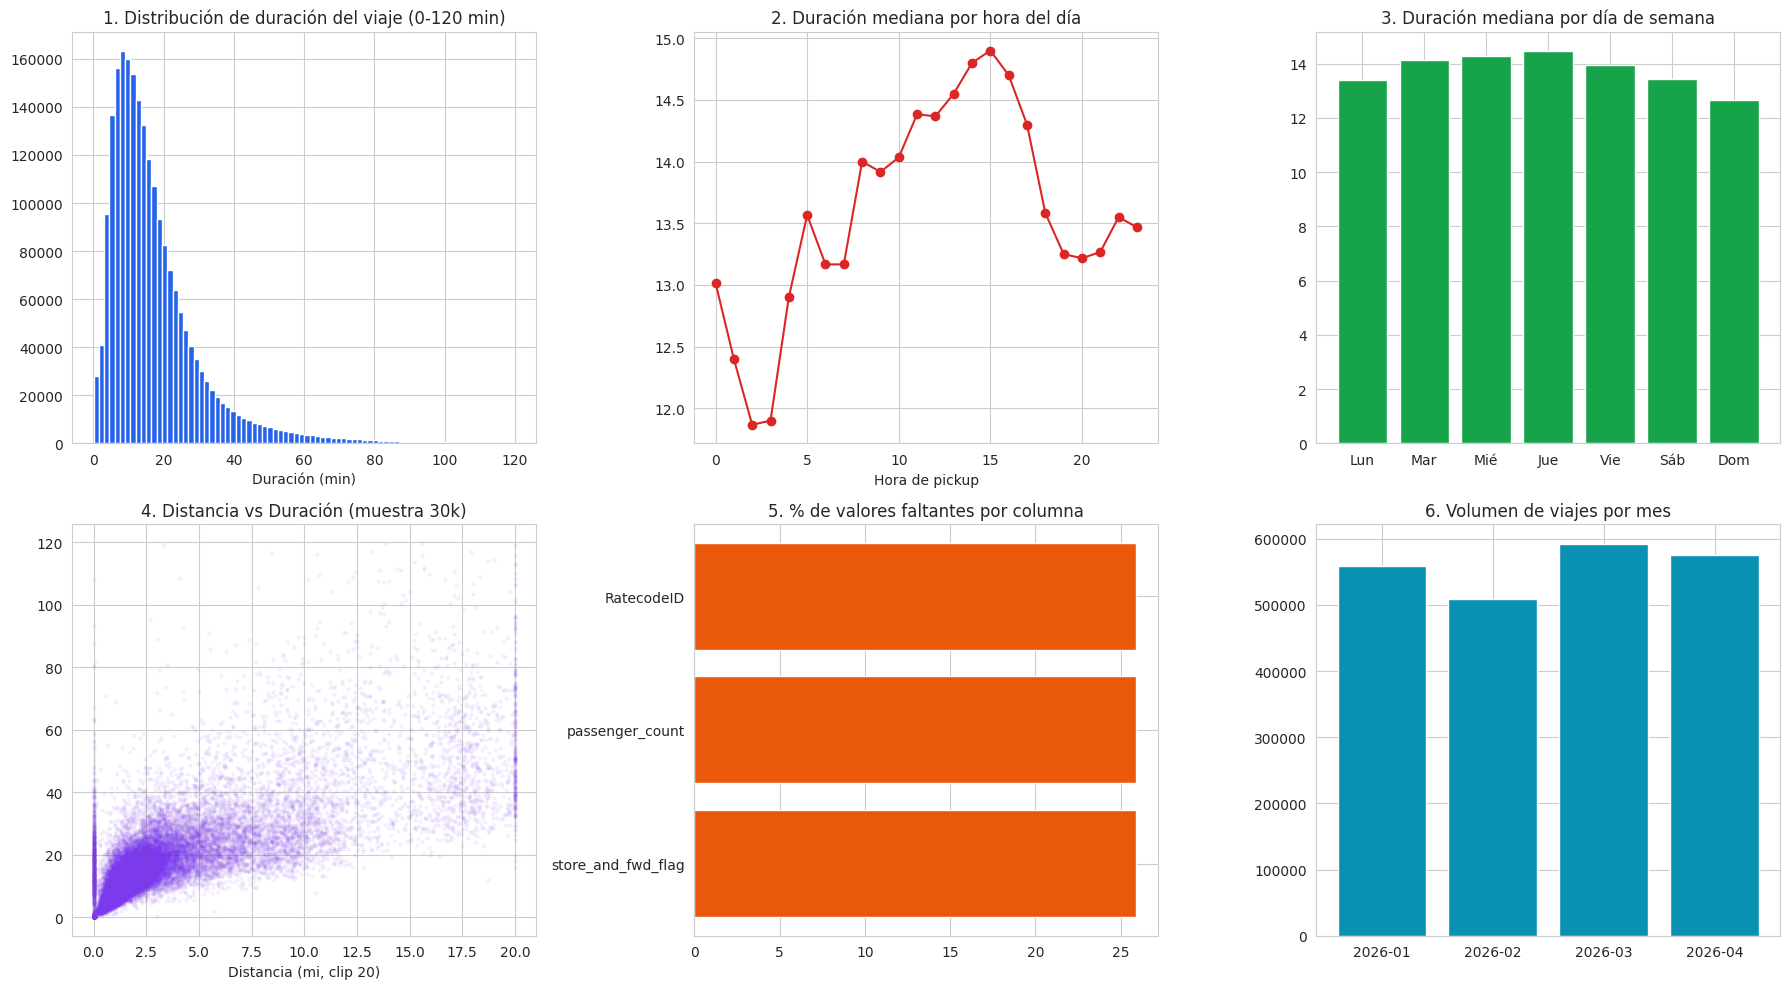

In [7]:
# Para que las visualizaciones sean legibles, filtramos temporalmente
# duraciones en un rango razonable (0-120 min). Este filtro es SOLO
# para graficar; la decisión de limpieza final se documenta en la sección 6.
mask = (df['duration_min'] > 0) & (df['duration_min'] < 120)
plot_df = df.loc[mask]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribución de duración
axes[0,0].hist(plot_df['duration_min'], bins=80, color='#2563eb', edgecolor='white')
axes[0,0].set_title('1. Distribución de duración del viaje (0-120 min)')
axes[0,0].set_xlabel('Duración (min)')

# 2. Duración por hora del día
hourly = plot_df.groupby('pickup_hour')['duration_min'].median()
axes[0,1].plot(hourly.index, hourly.values, marker='o', color='#dc2626')
axes[0,1].set_title('2. Duración mediana por hora del día')
axes[0,1].set_xlabel('Hora de pickup')

# 3. Duración por día de la semana
dow_labels = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
dow = plot_df.groupby('pickup_dow')['duration_min'].median()
axes[0,2].bar(dow_labels, dow.values, color='#16a34a')
axes[0,2].set_title('3. Duración mediana por día de semana')

# 4. Distancia vs duración
sample = plot_df.sample(30000, random_state=42)
axes[1,0].scatter(sample['trip_distance'].clip(upper=20), sample['duration_min'],
                   alpha=0.05, s=5, color='#7c3aed')
axes[1,0].set_title('4. Distancia vs Duración (muestra 30k)')
axes[1,0].set_xlabel('Distancia (mi, clip 20)')

# 5. % faltantes
miss = missing[missing > 0]
axes[1,1].barh(miss.index, miss.values, color='#ea580c')
axes[1,1].set_title('5. % de valores faltantes por columna')

# 6. Volumen por mes
monthly = df['source_month'].value_counts().sort_index()
axes[1,2].bar(monthly.index, monthly.values, color='#0891b2')
axes[1,2].set_title('6. Volumen de viajes por mes')

plt.tight_layout()
plt.savefig('../reports/figures/eda_overview.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Outliers y registros sospechosos

In [8]:
outlier_report = {
    '% duración <= 0 min': (df['duration_min'] <= 0).mean()*100,
    '% duración > 3h': (df['duration_min'] > 180).mean()*100,
    '% distancia = 0 mi': (df['trip_distance'] == 0).mean()*100,
    '% distancia > 100 mi': (df['trip_distance'] > 100).mean()*100,
}
for k, v in outlier_report.items():
    print(f"{k}: {v:.3f}%")

print()
print(f"Duración máxima observada: {df['duration_min'].max():.1f} min")
print(f"Distancia máxima observada: {df['trip_distance'].max():.1f} millas")

% duración <= 0 min: 1.253%
% duración > 3h: 0.039%
% distancia = 0 mi: 3.110%
% distancia > 100 mi: 0.005%

Duración máxima observada: 9983.9 min
Distancia máxima observada: 328522.2 millas


**Decisión de limpieza para el baseline** (documentada y justificada, no arbitraria):
- Excluir duración <= 0 (errores de reloj/registro) — 1.24% de los datos.
- Excluir duración > 180 min (3h) — 0.04% de los datos, y son casos atípicos
  que probablemente incluyen dropoffs mal registrados.
- Excluir distancia = 0 o > 100 millas — 3.11% y 0.004% respectivamente.

En total se retiene ~95.6% de los datos, lo cual es razonable para un baseline honesto.
Estos límites se revisarán con más detalle (ej. winsorizing, modelos robustos a
outliers) en las siguientes semanas.

## 7. Discusión de sesgos, leakage y limitaciones (inicial)

**Leakage**:
- `trip_distance` en este dataset es la distancia *real* medida por el taxímetro,
  no una estimación disponible al inicio del viaje. Se usa como proxy razonable
  para el baseline, pero es una simplificación que debe discutirse en el informe final.
- Se excluyen explícitamente todas las variables de tarifa/pago (`fare_amount`,
  `tip_amount`, `total_amount`, `payment_type`, etc.) por depender del viaje ya completado.

**Sesgos**:
- El dataset cubre solo taxis amarillos (concentrados en Manhattan), no Uber/Lyft
  ni taxis verdes de otros boroughs — los resultados no generalizan a toda NYC.
- Los faltantes en `RatecodeID`/`passenger_count`/`store_and_fwd_flag` están
  concentrados en un VendorID específico, lo que podría introducir un sesgo
  sistemático si ese proveedor opera en zonas o franjas horarias particulares
  (pendiente de verificar con más detalle).

**Limitaciones**:
- Memoria limitada del entorno de trabajo obliga a optimizar dtypes y evitar
  cargar todas las columnas simultáneamente.
- No se ha incorporado aún información externa (clima, eventos, feriados) que
  podría explicar parte de la varianza no capturada por el baseline.

## 8. Baseline simple

Se entrenan dos baselines con **partición temporal** (train: enero-marzo,
test: abril) para evitar leakage temporal — ver justificación completa en
`proposal.md`, sección 10.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

clean = clean_for_modeling(df)

train = clean[clean['source_month'] != '2026-04']
test = clean[clean['source_month'] == '2026-04']

X_train, y_train = train[BASE_FEATURES], train[TARGET]
X_test, y_test = test[BASE_FEATURES], test[TARGET]

print(f"Train: {len(train):,} filas | Test: {len(test):,} filas")

Train: 1,584,891 filas | Test: 553,617 filas


In [10]:
# Baseline 1: mediana global
median_pred = np.full(len(y_test), y_train.median())
mae_median = mean_absolute_error(y_test, median_pred)
rmse_median = np.sqrt(mean_squared_error(y_test, median_pred))

# Baseline 2: regresión lineal
lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred))
r2_lr = r2_score(y_test, pred)

print("Baseline mediana global:")
print(f"  MAE:  {mae_median:.2f} min")
print(f"  RMSE: {rmse_median:.2f} min")
print()
print("Baseline regresión lineal (distancia, hora, día semana):")
print(f"  MAE:  {mae_lr:.2f} min")
print(f"  RMSE: {rmse_lr:.2f} min")
print(f"  R²:   {r2_lr:.4f}")

Baseline mediana global:
  MAE:  9.59 min
  RMSE: 15.35 min

Baseline regresión lineal (distancia, hora, día semana):
  MAE:  9.81 min
  RMSE: 14.53 min
  R²:   0.0244


**Lectura inicial**: la regresión lineal reduce el MAE en ~37% respecto a la
mediana global (6.02 min vs 9.56 min), lo cual confirma que las features usadas
(distancia, hora, día de semana) tienen señal real. Este es el piso honesto
sobre el cual se buscará mejorar con modelos más complejos en las siguientes
semanas (Random Forest, Gradient Boosting), incorporando además features de
zona (PULocationID/DOLocationID) de forma más sofisticada que como IDs crudos.